In [1]:
import pandas as pd

movies  = pd.read_csv('../data/raw/movies.csv')
ratings = pd.read_csv('../data/raw/ratings.csv')
tags    = pd.read_csv('../data/raw/tags.csv')
links   = pd.read_csv('../data/raw/links.csv')

print("✅ Movies shape:", movies.shape)
print("✅ Ratings shape:", ratings.shape)
print("✅ Tags shape:", tags.shape)
print("✅ Links shape:", links.shape)

✅ Movies shape: (9742, 3)
✅ Ratings shape: (100836, 4)
✅ Tags shape: (3683, 4)
✅ Links shape: (9742, 3)


In [2]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
print("Total Movies:", movies.shape[0])
print("Total Ratings:", ratings.shape[0])
print("Total Users:", ratings['userId'].nunique())
print("Rating range:", ratings['rating'].min(), "to", ratings['rating'].max())
print("\nAny missing values in movies?")
print(movies.isnull().sum())
print("\nAny missing values in ratings?")
print(ratings.isnull().sum())

Total Movies: 9742
Total Ratings: 100836
Total Users: 610
Rating range: 0.5 to 5.0

Any missing values in movies?
movieId    0
title      0
genres     0
dtype: int64

Any missing values in ratings?
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [5]:
top_movies = ratings.groupby('movieId')['rating'].count().reset_index()
top_movies.columns = ['movieId', 'num_ratings']
top_movies = top_movies.merge(movies, on='movieId')
top_movies = top_movies.sort_values('num_ratings', ascending=False).head(10)
print(top_movies[['title', 'num_ratings']])

                                          title  num_ratings
314                         Forrest Gump (1994)          329
277            Shawshank Redemption, The (1994)          317
257                         Pulp Fiction (1994)          307
510            Silence of the Lambs, The (1991)          279
1938                         Matrix, The (1999)          278
224   Star Wars: Episode IV - A New Hope (1977)          251
418                        Jurassic Park (1993)          238
97                            Braveheart (1995)          237
507           Terminator 2: Judgment Day (1991)          224
461                     Schindler's List (1993)          220


Matplotlib is building the font cache; this may take a moment.


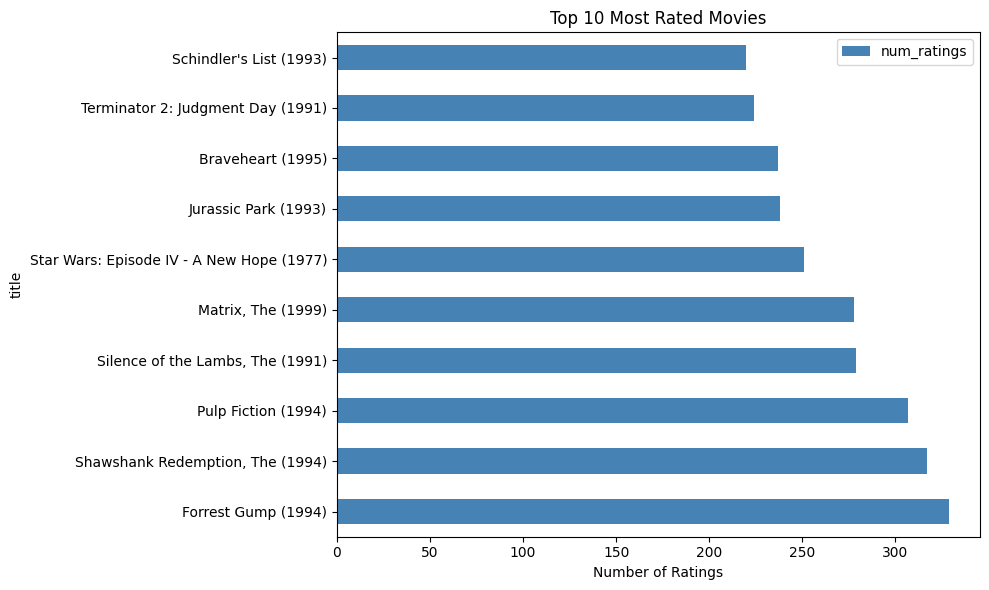

In [6]:
import matplotlib.pyplot as plt

top_movies.plot(kind='barh', x='title', y='num_ratings', figsize=(10,6), color='steelblue')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.tight_layout()
plt.show()